## *Operation Note*

*我々はコミュニケーションのためにEtherpad https://etherpad.org/ を改造した ep_weave https://github.com/NII-cloud-operation/ep_weave を利用しています。このNotebookではAWS上にep_weaveサーバーを構築してみます。*  

# マシンの確保

以下のセルは `05_OperationHubをAWSに構築.ipynb` の冒頭と同様です。そのため、nbsearchから取り込んでいます。 ... 詳細は検索の説明をご覧ください。

In [2]:
#%load_ext nbsearch.magics

In [3]:
# %%nbsearch
# query:
#   composition: AND
#   keyword:
#     _text_: aws configure
#     lc_cell_memes: e283d4cc-7517-11e7-a4c6-0242ac110002-15-1edf-23b9-eb94-1e7b-b177-4d38-4c16-1ff0-9d48-e21a
# sections:
#   - "# 事前条件"
#   - "# リソースの定義"
#   - "## CloudFormationのStack名"
#   - "## イメージのID"
#   - "## Keypairの準備"
#   - "# CloudFormation Stack作成"
#   - "## Templateの定義"
#   - "## Stackの作成"
#   - "## Security Groupの変更"
#   - "# Ansibleユーザの設定"
#   - "# Inventoryへの追記"

## 事前条件

**(05_OperationHubをAWSに構築.ipynbで構築したOperationHubから実行する場合は、すでにアカウントが設定されているため不要です)**

AWSアカウントを使用するため、事前にTerminalから、 `aws configure` を実施してください。

`aws configure` の実施例:

![aws-configure.svg](images/aws-configure.svg)


アクセスキー管理方法は様々ありますが、AWS IAMのユーザー https://console.aws.amazon.com/iam/home?region=us-west-2#/users からNotebook用のユーザーを作成する方法があります。万が一アクセスキーが漏れた場合に備えて、権限を最小限に、いつでも無効化できるように設定する必要があります。

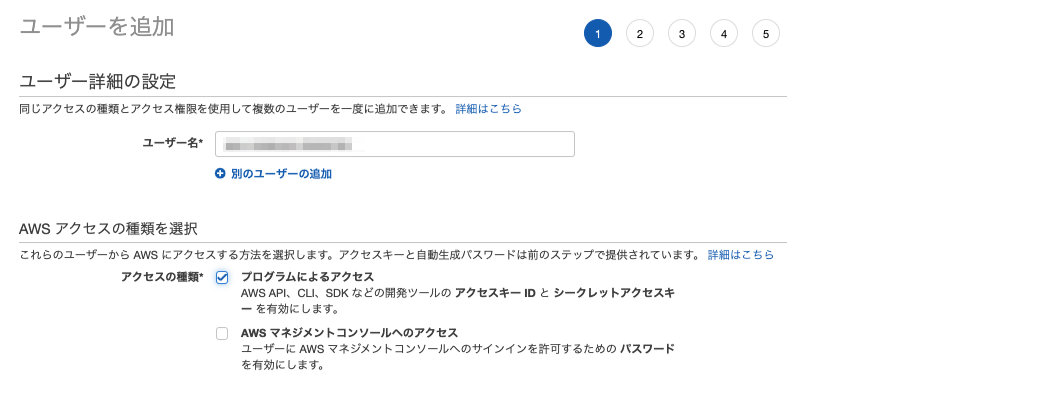

権限は `AmazonEC2FullAccess` と `AWSCloudFormationFullAccess` を想定しています。

正しくアクセス情報が指定されているかどうかを、`describe-vpcs`により確認します。**以下のコマンド実行がエラーとなる場合、`aws configure`が正しくなされていない可能性があります。**

In [4]:
import json
import sys

vpc_result = !aws ec2 describe-vpcs
try:
    vpcs = json.loads('\n'.join(vpc_result))['Vpcs']
    print('{} VPCs exist'.format(len(vpcs)))
except:
    print(vpc_result)
    raise sys.exc_info()

3 VPCs exist


本Notebookは、デモ用VPCとして、1つのVPCを追加します。

また、CloudFormationを利用してVPCやその他のリソースの準備を行います。CloudFormationのStackを1つ作成しますので、**本VMが不要になったら削除**してください。

In [5]:
stacks_result = !aws cloudformation list-stacks
try:
    stacks = json.loads('\n'.join(stacks_result))['StackSummaries']
    print('{} Stacks exist'.format(len(stacks)))
except:
    print(stacks_result)
    raise sys.exc_info()

4 Stacks exist


## リソースの定義



### CloudFormationのStack名

本Notebookが作成するリソースを管理するための CloudFormationのスタック名を設定してください。

In [6]:
cloudformation_stack_name = 'epweave0001'
cloudformation_stack_name

'epweave0001'

### イメージのID

イメージは Ubuntu 24.04を前提とする。

In [7]:
# Ubuntu 24.04
# ap-northeast-1を使用する場合
image_id = 'ami-054400ced365b82a0'

### Keypairの準備

使用するキーペア名を設定します。

In [8]:
resource_prefix = 'eptest'
resource_prefix

'eptest'

以下のセルは、誤ってRun Allでまとめ実行した際に先に進まないように設定しています。
これまでのセル実行が問題なければ、以下のコードセルを選択してFreezeボタンを押してFreezeして先に進めてください。

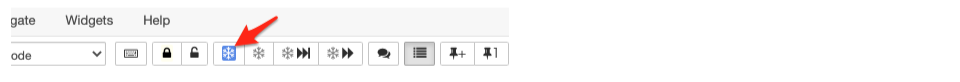

In [9]:
# ここまでのパラメータを確認したら本セルはFreezeして先に進める。
assert False

AssertionError: 

In [11]:
hostname = !hostname
keypair_name = '{}-{}'.format(resource_prefix, hostname[0])
keypair_name

'eptest-fc1d14b2d051'

本Notebookはインスタンスとの接続のために、 `~/.ssh/ansible_id_rsa` と言う名前の秘密鍵ファイルを生成します。
Notebook環境の `/home/jovyan` をホストディレクトリにマウントするなどして永続化していないと、この秘密鍵もコンテナの削除とともに消えますのでご注意ください。

> デモ用途なのでPassphraseなしで作っています。実際にはPassphraseをつけて、ssh-agentで鍵の取り回しをしています。

In [12]:
import os
ssh_keypath = os.path.expanduser('~/.ssh')
if not os.path.exists(os.path.join(ssh_keypath, 'ansible_id_rsa')):
    !ssh-keygen -t rsa -b 2048 -C ansible -f {ssh_keypath}/ansible_id_rsa -P ''
!cat {ssh_keypath}/ansible_id_rsa.pub

Generating public/private rsa key pair.
Created directory '/home/ohadmin/.ssh'.
Your identification has been saved in /home/ohadmin/.ssh/ansible_id_rsa
Your public key has been saved in /home/ohadmin/.ssh/ansible_id_rsa.pub
The key fingerprint is:
SHA256:r2Nb7tdZgr44y2Kcn2YI79KCANalM6nejeHAjUx9YAE ansible
The key's randomart image is:
+---[RSA 2048]----+
| E...            |
|   o .           |
|  + =            |
|.o B .           |
|=.+ +   S    .   |
| *.o  .  .  . . .|
|. +.+. = oo. . + |
| . +..o @=+oo o  |
|       *+OO+..   |
+----[SHA256]-----+
ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAABAQCw+rYeC4W6CM0tuVgW3b3RlYXsHuTk9W1h+3Xm4eQTGoPDhrU0EZuEdEn44s3J5nOuCMv665vRgm4FX6ZDasU8eK+i2hjzuqIkfUYB6+bRgP4P3aW+xjYiFCkumm+BRJiHe5E3EUNXbBeSr0CONWhR1W9wqdwAo3502wA+GcyCquc3R5SCQleJJPfP7h3ktKLJQcCfhH+AK14G8AFZadTjIMKcYR4KhKR0qSePDy0w1DxbsdH0LOH8RVB5Y60X6yvpYehNgn/gqn3fqknrtYOF7upzV/JA5mzD7Ow6IYVJ+KujQ5d/L5P86KaD8p0b//uLIJqAh48fpEPesK4UD0RV ansible


現在のキーの一覧を確認しておきます。

In [13]:
import json
result = !aws ec2 describe-key-pairs
keypairs = json.loads('\n'.join(result))['KeyPairs']
print('{} keys'.format(len(keypairs)))

28 keys


本Notebookは設定された resource_prefix 変数と hostname を使ってキーペア名を決定します。同一名称のキーペア名があれば特に何もしません。

In [14]:
import base64

if keypair_name not in [k['KeyName'] for k in keypairs]:
    with open(os.path.join(ssh_keypath, 'ansible_id_rsa.pub'), 'rb') as f:
        encoded_pub_key = base64.b64encode(f.read()).decode('utf8')
    !aws ec2 import-key-pair --key-name {keypair_name} --public-key-material {encoded_pub_key}

{
    "KeyFingerprint": "cf:5b:87:25:e6:29:ad:9e:bc:d6:d0:51:c4:7c:d8:26",
    "KeyName": "eptest-fc1d14b2d051",
    "KeyPairId": "key-0a3f00d0fdfdc491d"
}


## CloudFormation Stack作成

### Templateの定義

In [15]:
import tempfile
work_dir = tempfile.mkdtemp()
work_dir

'/tmp/tmpbqv_viq2'

In [16]:
%%writefile {work_dir}/template.yml
AWSTemplateFormatVersion: "2010-09-09"
Description: 'A template for OperationHub(DEMO)'
Parameters:
  KeyName:
    Type: String
        
  ImageId:
    Type: String

Resources:
  VPC:
    Type: "AWS::EC2::VPC"
    Properties:
      CidrBlock: 10.1.0.0/16
      EnableDnsSupport: true
      EnableDnsHostnames: true
      Tags:
      - Key: Name
        Value:  !Join ['', [!Ref "AWS::StackName", "-VPC" ]]
            
  InternetGateway:
    Type: "AWS::EC2::InternetGateway"
    DependsOn: VPC
        
  AttachGateway:
    Type: "AWS::EC2::VPCGatewayAttachment"
    Properties:
      VpcId: !Ref VPC
      InternetGatewayId: !Ref InternetGateway
        
  OpHubSubnet:
    Type: AWS::EC2::Subnet
    Properties:
      VpcId: !Ref VPC
      CidrBlock: 10.1.1.0/24
      AvailabilityZone: !Select [ 0, !GetAZs ]    # Get the first AZ in the list       
      Tags:
      - Key: Name
        Value: !Sub ${AWS::StackName}-OpHub
                
  OpHubPublicRouteTable:
    Type: AWS::EC2::RouteTable
    Properties:
      VpcId: !Ref VPC
      Tags:
      - Key: Name
        Value: OpHubPublic

  OpHubRoute1:
    Type: AWS::EC2::Route
    DependsOn: AttachGateway
    Properties:
      RouteTableId: !Ref OpHubPublicRouteTable
      DestinationCidrBlock: 0.0.0.0/0
      GatewayId: !Ref InternetGateway  
        
  OpHubPublicRouteTableAssociation:
    Type: AWS::EC2::SubnetRouteTableAssociation
    Properties:
      SubnetId: !Ref OpHubSubnet
      RouteTableId: !Ref OpHubPublicRouteTable
        
  OpHubSecurityGroup:
    Type: AWS::EC2::SecurityGroup
    Properties:
      GroupDescription: security group for OperationHub
      VpcId: !Ref VPC
      Tags:
      - Key: Name
        Value: !Sub ${AWS::StackName}-OpHubSG

  OpHubEIP:
    Type: AWS::EC2::EIP
    Properties:
      InstanceId: !Ref OpHubInstance

  OpHubInstance:
    Type: "AWS::EC2::Instance"
    Properties: 
      ImageId: !Ref ImageId
      InstanceType: t2.medium
      KeyName: !Ref KeyName
      SecurityGroupIds:
        - !Ref OpHubSecurityGroup
      SubnetId: !Ref OpHubSubnet
      Tags:
      - Key: Name
        Value: !Sub ${AWS::StackName}-OpHub
      BlockDeviceMappings:
        - DeviceName: /dev/sda1
          Ebs:
            VolumeSize: 50
            DeleteOnTermination: true

Outputs:
  OpHubInstanceId:
    Value: !Ref OpHubInstance

  OpHubIP:
    Value: !Ref OpHubEIP

  OpHubVPC:
    Value: !Ref VPC

  OpHubSubnet:
    Value: !Ref OpHubSubnet

  OpHubSecurityGroup:
    Value: !Ref OpHubSecurityGroup

Writing /tmp/tmpbqv_viq2/template.yml


### Stackの作成

Cloud FormationのStackを作成します。

In [17]:
stack_result = !aws cloudformation create-stack --stack-name {cloudformation_stack_name} \
    --parameters ParameterKey=KeyName,ParameterValue={keypair_name} ParameterKey=ImageId,ParameterValue={image_id} \
    --template-body file://{work_dir}/template.yml
try:
    stack_id = json.loads('\n'.join(stack_result))['StackId']
    print('StackId', stack_id)
except:
    print(stack_result)
    raise sys.exc_info()

StackId arn:aws:cloudformation:ap-northeast-1:274050600818:stack/epweave0001/c6e04440-4bdc-11f0-a5cb-0a93f207963f


以下のセルの実行結果に表示されるURLをクリックして、作成状況を確認してください。ステータスがCREATE_COMPLETEとなれば、Stackの作成は成功です。

In [18]:
import urllib.parse
regions = !aws configure get region
print('https://{region}.console.aws.amazon.com/cloudformation/home#/stacks/stackinfo?stackId={stack_id}'.format(region=regions[0], stack_id=urllib.parse.quote(stack_id)))

https://ap-northeast-1.console.aws.amazon.com/cloudformation/home#/stacks/stackinfo?stackId=arn%3Aaws%3Acloudformation%3Aap-northeast-1%3A274050600818%3Astack/epweave0001/c6e04440-4bdc-11f0-a5cb-0a93f207963f


**ステータスがCREATE_COMPLETEに変化したことを確認**したら、以下のセルを実行してください。

> 以下のセルは、Stack作成中の場合はエラーとなります。

In [23]:
describe_stack_result = !aws cloudformation describe-stacks --stack-name {stack_id}
stack_desc = json.loads(''.join(describe_stack_result))['Stacks'][0]
assert stack_desc['StackStatus'] == 'CREATE_COMPLETE', stack_desc['StackStatus']

## Security Groupの変更

CloudFormationにより、VMインスタンスが起動したようなので、Notebook環境から疎通確認をする。VMインスタンスのSecurity Groupは**デフォルトではどこからも接続を受け入れないようにしている**ので以下のURLから設定変更する。

AnsibleでのVM操作にはSSH(TCPポート22)を使用する。このJupyter Notebook環境からVMへのSSHアクセスを許可するよう適切なポートおよびアクセス元IPアドレスを指定する。**インバウンドルールを編集**ボタンを選択して、以下のようなルールを追加する。

> 以下ではマイIPを選択しているが、OperationHubの場合は、次のセル出力に現れるIPアドレスを許可する！

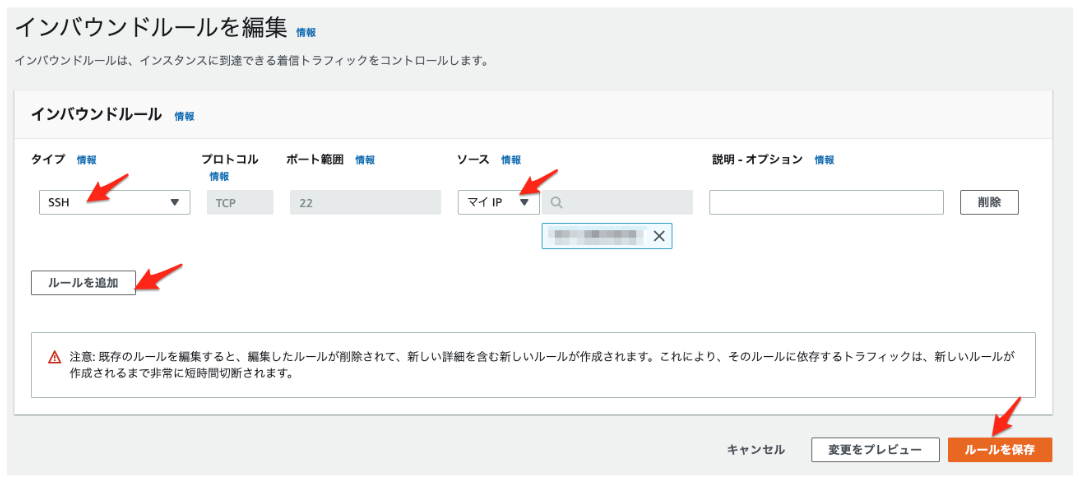

参考までに、このJupyter Notebookのアクセス元IPアドレスは以下となる。

> IPアドレスの取得に https://ifconfig.co サービスを使用します。

In [24]:
import requests
resp = requests.get('https://ifconfig.co/json')
resp.raise_for_status()
print(resp.json()['ip'])

18.179.171.165


Security GroupのIDはStackのOutputsに記録されている。

In [25]:
stack_desc['Outputs']

[{'OutputKey': 'OpHubSubnet', 'OutputValue': 'subnet-0b53f845887709acf'},
 {'OutputKey': 'OpHubIP', 'OutputValue': '57.183.73.254'},
 {'OutputKey': 'OpHubSecurityGroup', 'OutputValue': 'sg-057e4e62f68c0dc3b'},
 {'OutputKey': 'OpHubVPC', 'OutputValue': 'vpc-02aa3ded80206ef69'},
 {'OutputKey': 'OpHubInstanceId', 'OutputValue': 'i-017f23e04d1d0887e'}]

In [26]:
security_group_id = [o['OutputValue'] for o in stack_desc['Outputs'] if o['OutputKey'] == 'OpHubSecurityGroup'][0]
security_group_id

'sg-057e4e62f68c0dc3b'

上記の記述を参考に、以下のURLをクリックして設定変更を行う。

In [27]:
regions = !aws configure get region
print('https://{region}.console.aws.amazon.com/ec2/v2/home?region={region}#SecurityGroup:groupId={security_group_id}'.format(region=regions[0], security_group_id=security_group_id))

https://ap-northeast-1.console.aws.amazon.com/ec2/v2/home?region=ap-northeast-1#SecurityGroup:groupId=sg-057e4e62f68c0dc3b


In [29]:
# セキュリティグループにSSHに関する許可が含まれていれば先に進める
sg_result = !aws ec2 describe-security-groups --group-ids {security_group_id}
sg_desc = json.loads(''.join(sg_result))['SecurityGroups'][0]

assert 'IpPermissions' in sg_desc and any([ipperm['IpProtocol'] == 'tcp' and ipperm['ToPort'] <= 22 and 22 <= ipperm['FromPort'] for ipperm in sg_desc['IpPermissions']]), sg_desc['IpPermissions']

## Ansibleユーザの設定

Ansibleで対象マシンにアクセスできるよう、設定を実施します。

In [30]:
default_username = 'ubuntu'
default_username

'ubuntu'

In [31]:
import os

with open(os.path.join(work_dir, 'hosts'), 'w') as f:
    host = [o['OutputValue'] for o in stack_desc['Outputs'] if o['OutputKey'] == 'OpHubIP'][0]
    f.write('{host} ansible_ssh_user={user} ansible_ssh_private_key_file={pkpath} ansible_python_interpreter=/usr/bin/python3\n'.format(
        host=host,
        user=default_username,
        pkpath='~/.ssh/ansible_id_rsa',
    ))

!cat {work_dir}/hosts

57.183.73.254 ansible_ssh_user=ubuntu ansible_ssh_private_key_file=~/.ssh/ansible_id_rsa ansible_python_interpreter=/usr/bin/python3


In [32]:
%%writefile {work_dir}/init-password-aws
#!/usr/bin/expect

set host [lindex $argv 0]
set key [lindex $argv 1]
set username [lindex $argv 2]

spawn env LANG=C ssh -i $key "${username}\@${host}"

expect {
    -glob "(yes/no/*)?" {
        send "yes\n"
        exp_continue
    }
}

exit 0



Writing /tmp/tmpbqv_viq2/init-password-aws


In [33]:
import time

# VMのsshserverが落ち着くまで待つ...
time.sleep(30)

In [34]:
target_hostname = [o['OutputValue'] for o in stack_desc['Outputs'] if o['OutputKey'] == 'OpHubIP'][0]
!ssh-keygen -R {target_hostname} || exit 0
!expect {work_dir}/init-password-aws {target_hostname} ~/.ssh/ansible_id_rsa {default_username}

Cannot stat /home/ohadmin/.ssh/known_hosts: No such file or directory
spawn env LANG=C ssh -i /home/ohadmin/.ssh/ansible_id_rsa ubuntu@57.183.73.254
The authenticity of host '57.183.73.254 (57.183.73.254)' can't be established.
ED25519 key fingerprint is SHA256:OBoeTrR4vWDfQHbTApJcp3Bm3pQoDfAgpu0kJGSWSMI.
This key is not known by any other names.
Are you sure you want to continue connecting (yes/no/[fingerprint])? yes
Welcome to Ubuntu 24.04.2 LTS (GNU/Linux 6.8.0-1029-aws x86_64)

 * Documentation:  https://help.ubuntu.com
 * Management:     https://landscape.canonical.com
 * Support:        https://ubuntu.com/pro

 System information as of Wed Jun 18 00:43:43 UTC 2025

  System load:  0.12              Processes:             117
  Usage of /:   3.6% of 47.39GB   Users logged in:       0
  Memory usage: 5%                IPv4 address for enX0: 10.1.1.246
  Swap usage:   0%

Expanded Security Maintenance for Applications is not enabled.

0 updates can be applied immediately.

Enable ES

In [35]:
!ansible -m ping -i {work_dir}/hosts all

57.183.73.254 | SUCCESS => {
    "changed": false,
    "ping": "pong"
}


上記のセルがエラーとなる場合は、以下のように `-vvvv` オプションをつけてどんなメッセージが流れているかを確認してみましょう。

> !ansible -vvvv -m ping -i {work_dir}/hosts all
>
> Connection timed out の場合は、先のSecurity Groupがあっているかを確認すると良い...

OK。

## Inventoryへの追記

さてこれでVMが確保できました。Inventoryにhost情報を追記して、Ansibleからアクセスできるようにしましょう。


In [36]:
if not os.path.exists('./hosts'):
    !touch ./hosts
!cp ./hosts {work_dir}/hosts-backup

Inventoryに記述する例は以下のような感じ...

In [37]:
print('[{}]'.format(cloudformation_stack_name))
!cat {work_dir}/hosts

[epweave0001]
57.183.73.254 ansible_ssh_user=ubuntu ansible_ssh_private_key_file=~/.ssh/ansible_id_rsa ansible_python_interpreter=/usr/bin/python3


Inventoryを編集する。
1. [このNotebookがあるディレクトリ](/tree/) と同じ階層に `hosts` というファイルがあるので、これをクリックしてエディタを開く
2. 上記セルの出力 **2行分(スタック名とIPアドレスを含む)** をコピー＆ペーストする

`hosts`の変更差分を控えておく。

In [38]:
# ./hostsに変更を加えるとこのセルを通過できる
! ! diff -u {work_dir}/hosts-backup ./hosts

--- /tmp/tmpbqv_viq2/hosts-backup	2025-06-18 00:44:20.374530607 +0000
+++ ./hosts	2025-06-18 00:44:38.167673612 +0000
@@ -0,0 +1,2 @@
+[epweave0001]
+57.183.73.254 ansible_ssh_user=ubuntu ansible_ssh_private_key_file=~/.ssh/ansible_id_rsa ansible_python_interpreter=/usr/bin/python3
\ No newline at end of file


`hosts` ファイルのテストを実施する。

Ansibleに上記で設定したグループ名を与えてpingモジュールを実行する。

In [39]:
target_group = '-i ./hosts {}'.format(cloudformation_stack_name)
target_group

'-i ./hosts epweave0001'

In [40]:
!ansible -m ping {target_group}

57.183.73.254 | SUCCESS => {
    "changed": false,
    "ping": "pong"
}


これでVMの準備は完了です！

# Dockerのインストール

ep_weaveはDockerで起動します。

以下、 https://docs.docker.com/engine/install/ubuntu/ Install using the apt repositoryを参考に作成。

In [41]:
%%writefile {work_dir}/install-repo.sh
# Add Docker's official GPG key:
sudo apt-get update
sudo apt-get install ca-certificates curl
sudo install -m 0755 -d /etc/apt/keyrings
sudo curl -fsSL https://download.docker.com/linux/ubuntu/gpg -o /etc/apt/keyrings/docker.asc
sudo chmod a+r /etc/apt/keyrings/docker.asc

# Add the repository to Apt sources:
echo \
  "deb [arch=$(dpkg --print-architecture) signed-by=/etc/apt/keyrings/docker.asc] https://download.docker.com/linux/ubuntu \
  $(. /etc/os-release && echo "${UBUNTU_CODENAME:-$VERSION_CODENAME}") stable" | \
  sudo tee /etc/apt/sources.list.d/docker.list > /dev/null
sudo apt-get update

Writing /tmp/tmpbqv_viq2/install-repo.sh


In [42]:
!ansible -b -m copy -a 'src={work_dir}/install-repo.sh dest=install-docker-repo.sh' {target_group}
!ansible -b -a 'bash install-docker-repo.sh' {target_group}

57.183.73.254 | CHANGED => {
    "changed": true,
    "checksum": "5b945a762ac802cedacaaed60ea14eab61441e7f",
    "dest": "./install-docker-repo.sh",
    "gid": 0,
    "group": "root",
    "md5sum": "2b44e681e2f3377cfc938817c4576e48",
    "mode": "0644",
    "owner": "root",
    "size": 606,
    "src": "/home/ubuntu/.ansible/tmp/ansible-tmp-1750207491.935814-1315-73639862047144/.source.sh",
    "state": "file",
    "uid": 0
}
57.183.73.254 | CHANGED | rc=0 >>
Hit:1 http://ap-northeast-1.ec2.archive.ubuntu.com/ubuntu noble InRelease
Get:2 http://ap-northeast-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:3 http://ap-northeast-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:4 http://ap-northeast-1.ec2.archive.ubuntu.com/ubuntu noble/universe amd64 Packages [15.0 MB]
Get:5 http://ap-northeast-1.ec2.archive.ubuntu.com/ubuntu noble/universe Translation-en [5982 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:7 ht

In [43]:
!ansible -b -m apt -a 'name=docker-ce,docker-ce-cli,containerd.io,docker-buildx-plugin,docker-compose-plugin' {target_group}

57.183.73.254 | CHANGED => {
    "cache_update_time": 1750207522,
    "cache_updated": false,
    "changed": true,
    "stderr": "",
    "stderr_lines": [],
    "stdout": "Reading package lists...\nBuilding dependency tree...\nReading state information...\nThe following additional packages will be installed:\n  docker-ce-rootless-extras libltdl7 libslirp0 pigz slirp4netns\nSuggested packages:\n  cgroupfs-mount | cgroup-lite docker-model-plugin\nThe following NEW packages will be installed:\n  containerd.io docker-buildx-plugin docker-ce docker-ce-cli\n  docker-ce-rootless-extras docker-compose-plugin libltdl7 libslirp0 pigz\n  slirp4netns\n0 upgraded, 10 newly installed, 0 to remove and 6 not upgraded.\nNeed to get 121 MB of archives.\nAfter this operation, 445 MB of additional disk space will be used.\nGet:1 http://ap-northeast-1.ec2.archive.ubuntu.com/ubuntu noble/universe amd64 pigz amd64 2.8-1 [65.6 kB]\nGet:2 http://ap-northeast-1.ec2.archive.ubuntu.com/ubuntu noble/main amd64 lib

動作確認

In [44]:
!ansible -b -a 'docker run hello-world' {target_group}

57.183.73.254 | CHANGED | rc=0 >>

Hello from Docker!
This message shows that your installation appears to be working correctly.

To generate this message, Docker took the following steps:
 1. The Docker client contacted the Docker daemon.
 2. The Docker daemon pulled the "hello-world" image from the Docker Hub.
    (amd64)
 3. The Docker daemon created a new container from that image which runs the
    executable that produces the output you are currently reading.
 4. The Docker daemon streamed that output to the Docker client, which sent it
    to your terminal.

To try something more ambitious, you can run an Ubuntu container with:
 $ docker run -it ubuntu bash

Share images, automate workflows, and more with a free Docker ID:
 https://hub.docker.com/

For more examples and ideas, visit:
 https://docs.docker.com/get-started/Unable to find image 'hello-world:latest' locally
latest: Pulling from library/hello-world
e6590344b1a5: Pulling fs layer
e6590344b1a5: Verifying Checksum
e65903

# ep_weaveの配備

https://github.com/NII-cloud-operation/ep_weave を使う。

In [45]:
ep_dir = '/opt/ep_weave'

!ansible -b -m file -a 'path={ep_dir} state=directory' {target_group}

57.183.73.254 | CHANGED => {
    "changed": true,
    "gid": 0,
    "group": "root",
    "mode": "0755",
    "owner": "root",
    "path": "/opt/ep_weave",
    "size": 4096,
    "state": "directory",
    "uid": 0
}


git cloneする(あるいは更新を取り込む)。

In [46]:
!ansible -CDv -b -m git -a 'repo=https://github.com/NII-cloud-operation/ep_weave.git \
    dest={ep_dir}' {target_group}

Using /etc/ansible/ansible.cfg as config file
>> Newly checked out a0d2a5ad4c4311bce5557b1be9ba51e18c422ad4
57.183.73.254 | CHANGED => {
    "after": "a0d2a5ad4c4311bce5557b1be9ba51e18c422ad4",
    "before": null,
    "changed": true
}


In [47]:
!ansible -b -m git -a 'repo=https://github.com/NII-cloud-operation/ep_weave.git \
    dest={ep_dir}' {target_group}

57.183.73.254 | CHANGED => {
    "after": "a0d2a5ad4c4311bce5557b1be9ba51e18c422ad4",
    "before": null,
    "changed": true
}


設定を行う。設定を変更したい場合は https://github.com/NII-cloud-operation/ep_weave 等を参考にetherpad-local.jsonを変更する。

In [48]:
import tempfile
work_dir = tempfile.mkdtemp()
work_dir

'/tmp/tmpn4xei95a'

In [49]:
%%writefile {work_dir}/etherpad-local.json
/**
 * THIS IS THE SETTINGS FILE THAT IS COPIED INSIDE THE DOCKER CONTAINER.
 *
 * By default, some runtime customizations are supported (see the
 * documentation).
 *
 * If you need more control, edit this file and rebuild the container.
 */

/*
 * This file must be valid JSON. But comments are allowed
 *
 * Please edit settings.json, not settings.json.template
 *
 * Please note that starting from Etherpad 1.6.0 you can store DB credentials in
 * a separate file (credentials.json).
 *
 *
 * ENVIRONMENT VARIABLE SUBSTITUTION
 * =================================
 *
 * All the configuration values can be read from environment variables using the
 * syntax "${ENV_VAR}" or "${ENV_VAR:default_value}".
 *
 * This is useful, for example, when running in a Docker container.
 *
 * DETAILED RULES:
 *   - If the environment variable is set to the string "true" or "false", the
 *     value becomes Boolean true or false.
 *   - If the environment variable is set to the string "null", the value
 *     becomes null.
 *   - If the environment variable is set to the string "undefined", the setting
 *     is removed entirely, except when used as the member of an array in which
 *     case it becomes null.
 *   - If the environment variable is set to a string representation of a finite
 *     number, the string is converted to that number.
 *   - If the environment variable is set to any other string, including the
 *     empty string, the value is that string.
 *   - If the environment variable is unset and a default value is provided, the
 *     value is as if the environment variable was set to the provided default:
 *       - "${UNSET_VAR:}" becomes the empty string.
 *       - "${UNSET_VAR:foo}" becomes the string "foo".
 *       - "${UNSET_VAR:true}" and "${UNSET_VAR:false}" become true and false.
 *       - "${UNSET_VAR:null}" becomes null.
 *       - "${UNSET_VAR:undefined}" causes the setting to be removed (or be set
 *         to null, if used as a member of an array).
 *   - If the environment variable is unset and no default value is provided,
 *     the value becomes null. THIS BEHAVIOR MAY CHANGE IN A FUTURE VERSION OF
 *     ETHERPAD; if you want the default value to be null, you should explicitly
 *     specify "null" as the default value.
 *
 * EXAMPLE:
 *    "port":     "${PORT:9001}"
 *    "minify":   "${MINIFY}"
 *    "skinName": "${SKIN_NAME:colibris}"
 *
 * Would read the configuration values for those items from the environment
 * variables PORT, MINIFY and SKIN_NAME.
 *
 * If PORT and SKIN_NAME variables were not defined, the default values 9001 and
 * "colibris" would be used.
 * The configuration value "minify", on the other hand, does not have a
 * designated default value. Thus, if the environment variable MINIFY were
 * undefined, "minify" would be null.
 *
 * REMARKS:
 * 1) please note that variable substitution always needs to be quoted.
 *
 *    "port":     9001,            <-- Literal values. When not using
 *    "minify":   false                substitution, only strings must be
 *    "skinName": "colibris"           quoted. Booleans and numbers must not.
 *
 *    "port":     "${PORT:9001}"   <-- CORRECT: if you want to use a variable
 *    "minify":   "${MINIFY:true}"     substitution, put quotes around its name,
 *    "skinName": "${SKIN_NAME}"       even if the required value is a number or
 *                                     a boolean.
 *                                     Etherpad will take care of rewriting it
 *                                     to the proper type if necessary.
 *
 *    "port":     ${PORT:9001}     <-- ERROR: this is not valid json. Quotes
 *    "minify":   ${MINIFY}            around variable names are missing.
 *    "skinName": ${SKIN_NAME}
 *
 * 2) Beware of undefined variables and default values: nulls and empty strings
 *    are different!
 *
 *    This is particularly important for user's passwords (see the relevant
 *    section):
 *
 *    "password": "${PASSW}"  // if PASSW is not defined would result in password === null
 *    "password": "${PASSW:}" // if PASSW is not defined would result in password === ''
 *
 *    If you want to use an empty value (null) as default value for a variable,
 *    simply do not set it, without putting any colons: "${ABIWORD}".
 *
 * 3) if you want to use newlines in the default value of a string parameter,
 *    use "\n" as usual.
 *
 *    "defaultPadText" : "${DEFAULT_PAD_TEXT}Line 1\nLine 2"
 */
 {
  /*
   * Name your instance!
   */
  "title": "${TITLE:EP\ud83e\uddf6\ud83e\udea1}", /* Ball of Yarn and Sewing needle */

  /*
   * Pathname of the favicon you want to use. If null, the skin's favicon is
   * used if one is provided by the skin, otherwise the default Etherpad favicon
   * is used. If this is a relative path it is interpreted as relative to the
   * Etherpad root directory.
   */
  "favicon": "${FAVICON:null}",

  /*
   * Skin name.
   *
   * Its value has to be an existing directory under src/static/skins.
   * You can write your own, or use one of the included ones:
   *
   * - "no-skin":  an empty skin (default). This yields the unmodified,
   *               traditional Etherpad theme.
   * - "colibris": the new experimental skin (since Etherpad 1.8), candidate to
   *               become the default in Etherpad 2.0
   */
  "skinName": "${SKIN_NAME:colibris}",

  /*
   * Skin Variants
   *
   * Use the UI skin variants builder at /p/test#skinvariantsbuilder
   *
   * For the colibris skin only, you can choose how to render the three main
   * containers:
   * - toolbar (top menu with icons)
   * - editor (containing the text of the pad)
   * - background (area outside of editor, mostly visible when using page style)
   *
   * For each of the 3 containers you can choose 4 color combinations:
   * super-light, light, dark, super-dark.
   *
   * For example, to make the toolbar dark, you will include "dark-toolbar" into
   * skinVariants.
   *
   * You can provide multiple skin variants separated by spaces. Default
   * skinVariant is "super-light-toolbar super-light-editor light-background".
   *
   * For the editor container, you can also make it full width by adding
   * "full-width-editor" variant (by default editor is rendered as a page, with
   * a max-width of 900px).
   */
  "skinVariants": "${SKIN_VARIANTS:super-light-toolbar super-light-editor light-background}",

  /*
   * IP and port which Etherpad should bind at.
   *
   * Binding to a Unix socket is also supported: just use an empty string for
   * the ip, and put the full path to the socket in the port parameter.
   *
   * EXAMPLE USING UNIX SOCKET:
   *    "ip": "",                             // <-- has to be an empty string
   *    "port" : "/somepath/etherpad.socket", // <-- path to a Unix socket
   */
  "ip": "${IP:0.0.0.0}",
  "port": "${PORT:9001}",

  /*
   * Option to hide/show the settings.json in admin page.
   *
   * Default option is set to true
   */
  "showSettingsInAdminPage": "${SHOW_SETTINGS_IN_ADMIN_PAGE:true}",

  /*
   * Node native SSL support
   *
   * This is disabled by default.
   * Make sure to have the minimum and correct file access permissions set so
   * that the Etherpad server can access them
   */

  /*
  "ssl" : {
            "key"  : "/path-to-your/epl-server.key",
            "cert" : "/path-to-your/epl-server.crt",
            "ca": ["/path-to-your/epl-intermediate-cert1.crt", "/path-to-your/epl-intermediate-cert2.crt"]
          },
  */

  /*
   * The type of the database.
   *
   * You can choose between many DB drivers, for example: dirty, postgres,
   * sqlite, mysql.
   *
   * You shouldn't use "dirty" for for anything else than testing or
   * development.
   *
   *
   * Database specific settings are dependent on dbType, and go in dbSettings.
   * Remember that since Etherpad 1.6.0 you can also store this information in
   * credentials.json.
   *
   * For a complete list of the supported drivers, please refer to:
   * https://www.npmjs.com/package/ueberdb2
   */

  "dbType": "${DB_TYPE:dirty}",
  "dbSettings": {
    "host":       "${DB_HOST:undefined}",
    "port":       "${DB_PORT:undefined}",
    "database":   "${DB_NAME:undefined}",
    "user":       "${DB_USER:undefined}",
    "password":   "${DB_PASS:undefined}",
    "charset":    "${DB_CHARSET:undefined}",
    "filename":   "${DB_FILENAME:var/dirty.db}",
    "collection": "${DB_COLLECTION:undefined}",
    "url":        "${DB_URL:undefined}"
  },

  /*
   * The default text of a pad
   */
  "defaultPadText" : "${DEFAULT_PAD_TEXT:Welcome to Etherpad!\n\nThis pad text is synchronized as you type, so that everyone viewing this page sees the same text. This allows you to collaborate seamlessly on documents!\n\nGet involved with Etherpad at https:\/\/etherpad.org\n}",

  /*
   * Default Pad behavior.
   *
   * Change them if you want to override.
   */
  "padOptions": {
    "noColors":         "${PAD_OPTIONS_NO_COLORS:false}",
    "showControls":     "${PAD_OPTIONS_SHOW_CONTROLS:true}",
    "showChat":         "${PAD_OPTIONS_SHOW_CHAT:true}",
    "showLineNumbers":  "${PAD_OPTIONS_SHOW_LINE_NUMBERS:true}",
    "useMonospaceFont": "${PAD_OPTIONS_USE_MONOSPACE_FONT:false}",
    "userName":         "${PAD_OPTIONS_USER_NAME:null}",
    "userColor":        "${PAD_OPTIONS_USER_COLOR:null}",
    "rtl":              "${PAD_OPTIONS_RTL:false}",
    "alwaysShowChat":   "${PAD_OPTIONS_ALWAYS_SHOW_CHAT:false}",
    "chatAndUsers":     "${PAD_OPTIONS_CHAT_AND_USERS:false}",
    "lang":             "${PAD_OPTIONS_LANG:null}"
  },

  /*
   * Pad Shortcut Keys
   */
  "padShortcutEnabled" : {
    "altF9":     "${PAD_SHORTCUTS_ENABLED_ALT_F9:true}",      /* focus on the File Menu and/or editbar */
    "altC":      "${PAD_SHORTCUTS_ENABLED_ALT_C:true}",       /* focus on the Chat window */
    "cmdShift2": "${PAD_SHORTCUTS_ENABLED_CMD_SHIFT_2:true}", /* shows a gritter popup showing a line author */
    "delete":    "${PAD_SHORTCUTS_ENABLED_DELETE:true}",
    "return":    "${PAD_SHORTCUTS_ENABLED_RETURN:true}",
    "esc":       "${PAD_SHORTCUTS_ENABLED_ESC:true}",         /* in mozilla versions 14-19 avoid reconnecting pad */
    "cmdS":      "${PAD_SHORTCUTS_ENABLED_CMD_S:true}",       /* save a revision */
    "tab":       "${PAD_SHORTCUTS_ENABLED_TAB:true}",         /* indent */
    "cmdZ":      "${PAD_SHORTCUTS_ENABLED_CMD_Z:true}",       /* undo/redo */
    "cmdY":      "${PAD_SHORTCUTS_ENABLED_CMD_Y:true}",       /* redo */
    "cmdI":      "${PAD_SHORTCUTS_ENABLED_CMD_I:true}",       /* italic */
    "cmdB":      "${PAD_SHORTCUTS_ENABLED_CMD_B:true}",       /* bold */
    "cmdU":      "${PAD_SHORTCUTS_ENABLED_CMD_U:true}",       /* underline */
    "cmd5":      "${PAD_SHORTCUTS_ENABLED_CMD_5:true}",       /* strike through */
    "cmdShiftL": "${PAD_SHORTCUTS_ENABLED_CMD_SHIFT_L:true}", /* unordered list */
    "cmdShiftN": "${PAD_SHORTCUTS_ENABLED_CMD_SHIFT_N:true}", /* ordered list */
    "cmdShift1": "${PAD_SHORTCUTS_ENABLED_CMD_SHIFT_1:true}", /* ordered list */
    "cmdH":      "${PAD_SHORTCUTS_ENABLED_CMD_H:true}",       /* backspace */
    "ctrlHome":  "${PAD_SHORTCUTS_ENABLED_CTRL_HOME:true}",   /* scroll to top of pad */
    "pageUp":    "${PAD_SHORTCUTS_ENABLED_PAGE_UP:true}",
    "pageDown":  "${PAD_SHORTCUTS_ENABLED_PAGE_DOWN:true}"
  },

  /*
   * Should we suppress errors from being visible in the default Pad Text?
   */
  "suppressErrorsInPadText": "${SUPPRESS_ERRORS_IN_PAD_TEXT:false}",

  /*
   * If this option is enabled, a user must have a session to access pads.
   * This effectively allows only group pads to be accessed.
   */
  "requireSession": "${REQUIRE_SESSION:false}",

  /*
   * Users may edit pads but not create new ones.
   *
   * Pad creation is only via the API.
   * This applies both to group pads and regular pads.
   */
  "editOnly": "true",

  /*
   * If true, all css & js will be minified before sending to the client.
   *
   * This will improve the loading performance massively, but makes it difficult
   * to debug the javascript/css
   */
  "minify": "${MINIFY:true}",

  /*
   * How long may clients use served javascript code (in seconds)?
   *
   * Not setting this may cause problems during deployment.
   * Set to 0 to disable caching.
   */
  "maxAge": "${MAX_AGE:21600}", // 60 * 60 * 6 = 6 hours

  /*
   * Absolute path to the Abiword executable.
   *
   * Abiword is needed to get advanced import/export features of pads. Setting
   * it to null disables Abiword and will only allow plain text and HTML
   * import/exports.
   */
  "abiword": "${ABIWORD:null}",

  /*
   * This is the absolute path to the soffice executable.
   *
   * LibreOffice can be used in lieu of Abiword to export pads.
   * Setting it to null disables LibreOffice exporting.
   */
  "soffice": "${SOFFICE:null}",

  /*
   * Allow import of file types other than the supported ones:
   * txt, doc, docx, rtf, odt, html & htm
   */
  "allowUnknownFileEnds": "${ALLOW_UNKNOWN_FILE_ENDS:true}",

  /*
   * This setting is used if you require authentication of all users.
   *
   * Note: "/admin" always requires authentication.
   */
  "requireAuthentication": "${REQUIRE_AUTHENTICATION:false}",

  /*
   * Require authorization by a module, or a user with is_admin set, see below.
   */
  "requireAuthorization": "${REQUIRE_AUTHORIZATION:false}",

  /*
   * When you use NGINX or another proxy/load-balancer set this to true.
   *
   * This is especially necessary when the reverse proxy performs SSL
   * termination, otherwise the cookies will not have the "secure" flag.
   *
   * The other effect will be that the logs will contain the real client's IP,
   * instead of the reverse proxy's IP.
   */
  "trustProxy": "${TRUST_PROXY:false}",

  /*
   * Settings controlling the session cookie issued by Etherpad.
   */
  "cookie": {
    /*
     * How often (in milliseconds) the key used to sign the express_sid cookie
     * should be rotated. Long rotation intervals reduce signature verification
     * overhead (because there are fewer historical keys to check) and database
     * load (fewer historical keys to store, and less frequent queries to
     * get/update the keys). Short rotation intervals are slightly more secure.
     *
     * Multiple Etherpad processes sharing the same database (table) is
     * supported as long as the clock sync error is significantly less than this
     * value.
     *
     * Key rotation can be disabled (not recommended) by setting this to 0 or
     * null, or by disabling session expiration (see sessionLifetime).
     */
    // 86400000 = 1d * 24h/d * 60m/h * 60s/m * 1000ms/s
    "keyRotationInterval": "${COOKIE_KEY_ROTATION_INTERVAL:86400000}",

    /*
     * Value of the SameSite cookie property. "Lax" is recommended unless
     * Etherpad will be embedded in an iframe from another site, in which case
     * this must be set to "None". Note: "None" will not work (the browser will
     * not send the cookie to Etherpad) unless https is used to access Etherpad
     * (either directly or via a reverse proxy with "trustProxy" set to true).
     *
     * "Strict" is not recommended because it has few security benefits but
     * significant usability drawbacks vs. "Lax". See
     * https://stackoverflow.com/q/41841880 for discussion.
     */
    "sameSite": "${COOKIE_SAME_SITE:Lax}",

    /*
     * How long (in milliseconds) after navigating away from Etherpad before the
     * user is required to log in again. (The express_sid cookie is set to
     * expire at time now + sessionLifetime when first created, and its
     * expiration time is periodically refreshed to a new now + sessionLifetime
     * value.) If requireAuthentication is false then this value does not really
     * matter.
     *
     * The "best" value depends on your users' usage patterns and the amount of
     * convenience you desire. A long lifetime is more convenient (users won't
     * have to log back in as often) but has some drawbacks:
     *   - It increases the amount of state kept in the database.
     *   - It might weaken security somewhat: The cookie expiration is refreshed
     *     indefinitely without consulting authentication or authorization
     *     hooks, so once a user has accessed a pad, the user can continue to
     *     use the pad until the user leaves for longer than sessionLifetime.
     *   - More historical keys (sessionLifetime / keyRotationInterval) must be
     *     checked when verifying signatures.
     *
     * Session lifetime can be set to infinity (not recommended) by setting this
     * to null or 0. Note that if the session does not expire, most browsers
     * will delete the cookie when the browser exits, but a session record is
     * kept in the database forever.
     */
    // 864000000 = 10d * 24h/d * 60m/h * 60s/m * 1000ms/s
    "sessionLifetime": "${COOKIE_SESSION_LIFETIME:864000000}",

    /*
     * How long (in milliseconds) before the expiration time of an active user's
     * session is refreshed (to now + sessionLifetime). This setting affects the
     * following:
     *   - How often a new session expiration time will be written to the
     *     database.
     *   - How often each user's browser will ping the Etherpad server to
     *     refresh the expiration time of the session cookie.
     *
     * High values reduce the load on the database and the load from browsers,
     * but can shorten the effective session lifetime if Etherpad is restarted
     * or the user navigates away.
     *
     * Automatic session refreshes can be disabled (not recommended) by setting
     * this to null.
     */
    // 86400000 = 1d * 24h/d * 60m/h * 60s/m * 1000ms/s
    "sessionRefreshInterval": "${COOKIE_SESSION_REFRESH_INTERVAL:86400000}"
  },

  /*
   * Privacy: disable IP logging
   */
  "disableIPlogging": "${DISABLE_IP_LOGGING:false}",

  /*
   * Time (in seconds) to automatically reconnect pad when a "Force reconnect"
   * message is shown to user.
   *
   * Set to 0 to disable automatic reconnection.
   */
  "automaticReconnectionTimeout": "${AUTOMATIC_RECONNECTION_TIMEOUT:0}",

  /*
   * By default, when caret is moved out of viewport, it scrolls the minimum
   * height needed to make this line visible.
   */
  "scrollWhenFocusLineIsOutOfViewport": {

    /*
     * Percentage of viewport height to be additionally scrolled.
     *
     * E.g.: use "percentage.editionAboveViewport": 0.5, to place caret line in
     *       the middle of viewport, when user edits a line above of the
     *       viewport
     *
     * Set to 0 to disable extra scrolling
     */
    "percentage": {
      "editionAboveViewport": "${FOCUS_LINE_PERCENTAGE_ABOVE:0}",
      "editionBelowViewport": "${FOCUS_LINE_PERCENTAGE_BELOW:0}"
    },

    /*
     * Time (in milliseconds) used to animate the scroll transition.
     * Set to 0 to disable animation
     */
    "duration": "${FOCUS_LINE_DURATION:0}",

    /*
     * Flag to control if it should scroll when user places the caret in the
     * last line of the viewport
     */
    "scrollWhenCaretIsInTheLastLineOfViewport": "${FOCUS_LINE_CARET_SCROLL:false}",

    /*
     * Percentage of viewport height to be additionally scrolled when user
     * presses arrow up in the line of the top of the viewport.
     *
     * Set to 0 to let the scroll to be handled as default by Etherpad
     */
    "percentageToScrollWhenUserPressesArrowUp": "${FOCUS_LINE_PERCENTAGE_ARROW_UP:0}"
  },

  /*
   * User accounts. These accounts are used by:
   *   - default HTTP basic authentication if no plugin handles authentication
   *   - some but not all authentication plugins
   *   - some but not all authorization plugins
   *
   * User properties:
   *   - password: The user's password. Some authentication plugins will ignore
   *     this.
   *   - is_admin: true gives access to /admin. Defaults to false. If you do not
   *     uncomment this, /admin will not be available!
   *   - readOnly: If true, this user will not be able to create new pads or
   *     modify existing pads. Defaults to false.
   *   - canCreate: If this is true and readOnly is false, this user can create
   *     new pads. Defaults to true.
   *
   * Authentication and authorization plugins may define additional properties.
   *
   * WARNING: passwords should not be stored in plaintext in this file.
   *          If you want to mitigate this, please install ep_hash_auth and
   *          follow the section "secure your installation" in README.md
   */

  "users": {
    "admin": {
      // 1) "password" can be replaced with "hash" if you install ep_hash_auth
      // 2) please note that if password is null, the user will not be created
      "password": "${ADMIN_PASSWORD:null}",
      "is_admin": true
    },
    "user": {
      // 1) "password" can be replaced with "hash" if you install ep_hash_auth
      // 2) please note that if password is null, the user will not be created
      "password": "${USER_PASSWORD:null}",
      "is_admin": false
    },
  },

  /*
   * Restrict socket.io transport methods
   */
  "socketTransportProtocols" : ["websocket", "polling"],

  "socketIo": {
    /*
     * Maximum permitted client message size (in bytes). All messages from
     * clients that are larger than this will be rejected. Large values make it
     * possible to paste large amounts of text, and plugins may require a larger
     * value to work properly, but increasing the value increases susceptibility
     * to denial of service attacks (malicious clients can exhaust memory).
     */
    "maxHttpBufferSize": "${SOCKETIO_MAX_HTTP_BUFFER_SIZE:10000}"
  },

  /*
   * Allow Load Testing tools to hit the Etherpad Instance.
   *
   * WARNING: this will disable security on the instance.
   */
  "loadTest": "${LOAD_TEST:false}",

  /**
  * Disable dump of objects preventing a clean exit
  */
  "dumpOnUncleanExit": "${DUMP_ON_UNCLEAN_EXIT:false}",

  /*
   * Disable indentation on new line when previous line ends with some special
   * chars (':', '[', '(', '{')
   */

  /*
  "indentationOnNewLine": false,
  */

  /*
   * From Etherpad 1.8.3 onwards, import and export of pads is always rate
   * limited.
   *
   * The default is to allow at most 10 requests per IP in a 90 seconds window.
   * After that the import/export request is rejected.
   *
   * See https://github.com/nfriedly/express-rate-limit for more options
   */
  "importExportRateLimiting": {
    // duration of the rate limit window (milliseconds)
    "windowMs": "${IMPORT_EXPORT_RATE_LIMIT_WINDOW:90000}",

    // maximum number of requests per IP to allow during the rate limit window
    "max": "${IMPORT_EXPORT_MAX_REQ_PER_IP:10}"
  },

  /*
   * From Etherpad 1.8.3 onwards, the maximum allowed size for a single imported
   * file is always bounded.
   *
   * File size is specified in bytes. Default is 50 MB.
   */
  "importMaxFileSize": "${IMPORT_MAX_FILE_SIZE:52428800}", // 50 * 1024 * 1024

  /*
   * From Etherpad 1.8.5 onwards, when Etherpad is in production mode commits from individual users are rate limited
   *
   * The default is to allow at most 10 changes per IP in a 1 second window.
   * After that the change is rejected.
   *
   * See https://github.com/animir/node-rate-limiter-flexible/wiki/Overall-example#websocket-single-connection-prevent-flooding for more options
   */
  "commitRateLimiting": {
    // duration of the rate limit window (seconds)
    "duration": "${COMMIT_RATE_LIMIT_DURATION:1}",

    // maximum number of changes per IP to allow during the rate limit window
    "points": "${COMMIT_RATE_LIMIT_POINTS:10}"
  },

  /*
   * Toolbar buttons configuration.
   */
  "toolbar": {
    "left": [
      ["bold", "italic", "underline", "strikethrough"],
      ["orderedlist", "unorderedlist", "indent", "outdent"],
      ["undo", "redo"]
    ],
    "right": [
      ["importexport", "timeslider", "savedrevision"],
      ["settings", "embed"],
      ["showusers"]
    ],
    "timeslider": [
      ["timeslider_export", "timeslider_settings", "timeslider_returnToPad"]
    ]
  },

  /*
   * Expose Etherpad version in the web interface and in the Server http header.
   *
   * Do not enable on production machines.
   */
  "exposeVersion": "${EXPOSE_VERSION:false}",

  /*
   * The log level we are using.
   *
   * Valid values: DEBUG, INFO, WARN, ERROR
   */
  "loglevel": "${LOGLEVEL:INFO}",

  /* Override any strings found in locale directories */
  "customLocaleStrings": {},

  /* Disable Admin UI tests */
  "enableAdminUITests": false,

  /*
   * Enable/Disable case-insensitive pad names.
   */
  "lowerCasePadIds": "${LOWER_CASE_PAD_IDS:false}",

  "ep_search": {
    "type": "solr",
    "host": "solr",
    "port": "8983",
    "core": "pad",
    "padSerializer": "ep_weave/lib/serializer"
  }
}

Writing /tmp/tmpn4xei95a/etherpad-local.json


In [50]:
# !ansible -b -CDv -m copy -a 'src={work_dir}/docker-compose.override.yml \
#     dest={ep_dir}/docker-compose.override.yml' {target_host}
!ansible -CDv -b -m copy -a 'src={work_dir}/etherpad-local.json \
    dest={ep_dir}/demo/local.json' {target_group}

Using /etc/ansible/ansible.cfg as config file
--- before
+++ after: /tmp/tmpn4xei95a/etherpad-local.json
@@ -0,0 +1,655 @@
+/**
+ * THIS IS THE SETTINGS FILE THAT IS COPIED INSIDE THE DOCKER CONTAINER.
+ *
+ * By default, some runtime customizations are supported (see the
+ * documentation).
+ *
+ * If you need more control, edit this file and rebuild the container.
+ */
+
+/*
+ * This file must be valid JSON. But comments are allowed
+ *
+ * Please edit settings.json, not settings.json.template
+ *
+ * Please note that starting from Etherpad 1.6.0 you can store DB credentials in
+ * a separate file (credentials.json).
+ *
+ *
+ * ENVIRONMENT VARIABLE SUBSTITUTION
+ * =================================
+ *
+ * All the configuration values can be read from environment variables using the
+ * syntax "${ENV_VAR}" or "${ENV_VAR:default_value}".
+ *
+ * This is useful, for example, when running in a Docker container.
+ *
+ * DETAILED RULES:
+ *   - If the environment variable is set to the s

In [51]:
# !ansible -b -m copy -a 'src={work_dir}/docker-compose.override.yml \
#     dest={ep_dir}/docker-compose.override.yml' {target_host}
!ansible -b -m copy -a 'src={work_dir}/etherpad-local.json \
    dest={ep_dir}/demo/local.json' {target_group}

57.183.73.254 | CHANGED => {
    "changed": true,
    "checksum": "e44d1bcef6db18cacaaee1a25f48cc7f6d37f1f2",
    "dest": "/opt/ep_weave/demo/local.json",
    "gid": 0,
    "group": "root",
    "md5sum": "2dff1650370f569fcf4d48506a598329",
    "mode": "0644",
    "owner": "root",
    "size": 24801,
    "src": "/home/ubuntu/.ansible/tmp/ansible-tmp-1750207561.1092343-1618-211855474500588/.source.json",
    "state": "file",
    "uid": 0
}


## 起動

ビルドして動作確認する。

In [52]:
!ansible -b -a 'chdir={ep_dir} docker compose build --pull' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
Compose can now delegate builds to bake for better performance.
 To do so, set COMPOSE_BAKE=true.
#0 building with "default" instance using docker driver

#1 [solr internal] load build definition from Dockerfile
#1 transferring dockerfile: 252B done
#1 DONE 0.0s

#2 [solr internal] load metadata for docker.io/library/solr:8
#2 DONE 1.7s

#3 [solr internal] load .dockerignore
#3 transferring context: 68B done
#3 DONE 0.0s

#4 [solr 1/3] FROM docker.io/library/solr:8@sha256:122a041ef84b9567336ebfd7769512fc21a476cee740ce7b06c5971fd7055710
#4 resolve docker.io/library/solr:8@sha256:122a041ef84b9567336ebfd7769512fc21a476cee740ce7b06c5971fd7055710 0.0s done
#4 ...

#5 [solr internal] load build context
#5 transferring context: 2.05MB 0.0s done
#5 DONE 0.1s

#4 [solr 1/3] FROM docker.io/library/solr:8@sha256:122a041ef84b9567336ebfd7769512fc21a476cee740ce7b06c5971fd7055710
#4 sha256:122a041ef84b9567336ebfd7769512fc21a476cee740ce7b06c5971fd7055710 5.14kB / 5.14

In [53]:
!ansible -b -a 'chdir={ep_dir} docker compose up -d' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
time="2025-06-18T00:48:38Z" level=warning msg="/opt/ep_weave/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion"
 postgresql Pulling 
 dad67da3f26b Pulling fs layer 
 c6667110959a Pulling fs layer 
 a6ef02a978c3 Pulling fs layer 
 02cc8cf6d8dd Pulling fs layer 
 f4c4a9a671ae Pulling fs layer 
 8ee74200f81b Pulling fs layer 
 598745af2ec7 Pulling fs layer 
 ecd27617158f Pulling fs layer 
 f461e2873ab2 Pulling fs layer 
 3e33fda50871 Pulling fs layer 
 5d4c65957a72 Pulling fs layer 
 6b0f5168a1c6 Pulling fs layer 
 cab1e29ab063 Pulling fs layer 
 9e594ba6e3d2 Pulling fs layer 
 02cc8cf6d8dd Waiting 
 f4c4a9a671ae Waiting 
 8ee74200f81b Waiting 
 598745af2ec7 Waiting 
 ecd27617158f Waiting 
 f461e2873ab2 Waiting 
 3e33fda50871 Waiting 
 5d4c65957a72 Waiting 
 6b0f5168a1c6 Waiting 
 cab1e29ab063 Waiting 
 9e594ba6e3d2 Waiting 
 c6667110959a Downloading     934B/1.166kB
 c6667110959a Do

healthyになるまで待つ。

In [54]:
!ansible -b -a 'chdir={ep_dir} docker compose ps' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
NAME                    IMAGE               COMMAND                  SERVICE      CREATED         STATUS                           PORTS
ep_weave-etherpad-1     ep_weave-etherpad   "docker-entrypoint.s…"   etherpad     2 seconds ago   Up 1 second (health: starting)   0.0.0.0:9001->9001/tcp, [::]:9001->9001/tcp
ep_weave-postgresql-1   postgres:15         "docker-entrypoint.s…"   postgresql   5 seconds ago   Up 2 seconds                     5432/tcp
ep_weave-solr-1         ep_weave-solr       "/bin/sh -c /opt/ep_…"   solr         5 seconds ago   Up 2 seconds                     8983/tcptime="2025-06-18T00:48:54Z" level=warning msg="/opt/ep_weave/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion"


In [55]:
!ansible -b -a 'chdir={ep_dir} docker compose logs etherpad' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
etherpad-1  | 
etherpad-1  | > etherpad@2.3.0 prod /opt/etherpad-lite
etherpad-1  | > pnpm --filter ep_etherpad-lite run prod
etherpad-1  | 
etherpad-1  | 
etherpad-1  | > ep_etherpad-lite@2.3.0 prod /opt/etherpad-lite/src
etherpad-1  | > cross-env NODE_ENV=production node --require tsx/cjs node/server.ts
etherpad-1  | time="2025-06-18T00:48:56Z" level=warning msg="/opt/ep_weave/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion"


## 動作確認

動作確認する。9001番ポートへのアクセスを許可する必要あり。

自身のPCからVMのTCP 9001番ポートを許可するように設定する。SSHの設定と同じ要領でOK。アクセス元IPアドレスは動作確認をするPCのものを指定すること。

In [57]:
regions = !aws configure get region
print('https://{region}.console.aws.amazon.com/ec2/v2/home?region={region}#SecurityGroup:groupId={security_group_id}'.format(region=regions[0], security_group_id=security_group_id))

https://ap-northeast-1.console.aws.amazon.com/ec2/v2/home?region=ap-northeast-1#SecurityGroup:groupId=sg-057e4e62f68c0dc3b


In [59]:
# セキュリティグループに9001に関する許可が含まれていれば先に進める
sg_result = !aws ec2 describe-security-groups --group-ids {security_group_id}
sg_desc = json.loads(''.join(sg_result))['SecurityGroups'][0]

assert 'IpPermissions' in sg_desc and any([ipperm['IpProtocol'] == 'tcp' and ipperm['ToPort'] <= 9001 and 9001 <= ipperm['FromPort'] for ipperm in sg_desc['IpPermissions']]), sg_desc['IpPermissions']

以下のURLにブラウザからアクセスする。


In [60]:
print('http://' + target_hostname + ':9001')

http://57.183.73.254:9001


以下のような画面が表示されれば成功です。

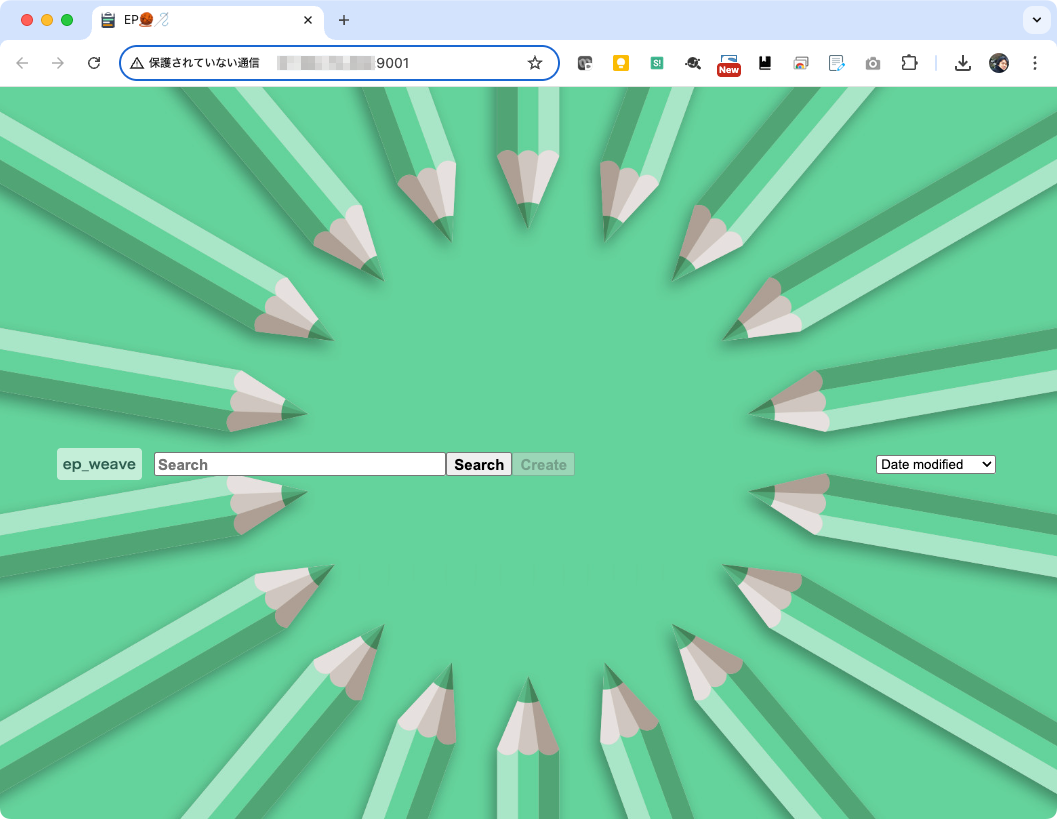

サービスの状態・ログは以下から確認することができます。

In [61]:
!ansible -b -a 'chdir={ep_dir} docker compose ps' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
NAME                    IMAGE               COMMAND                  SERVICE      CREATED          STATUS                    PORTS
ep_weave-etherpad-1     ep_weave-etherpad   "docker-entrypoint.s…"   etherpad     33 seconds ago   Up 32 seconds (healthy)   0.0.0.0:9001->9001/tcp, [::]:9001->9001/tcp
ep_weave-postgresql-1   postgres:15         "docker-entrypoint.s…"   postgresql   36 seconds ago   Up 33 seconds             5432/tcp
ep_weave-solr-1         ep_weave-solr       "/bin/sh -c /opt/ep_…"   solr         36 seconds ago   Up 33 seconds             8983/tcptime="2025-06-18T00:49:25Z" level=warning msg="/opt/ep_weave/docker-compose.yml: the attribute `version` is obsolete, it will be ignored, please remove it to avoid potential confusion"


In [62]:
!ansible -b -a 'chdir={ep_dir} docker compose logs etherpad' {target_group}

57.183.73.254 | CHANGED | rc=0 >>
etherpad-1  | 
etherpad-1  | > etherpad@2.3.0 prod /opt/etherpad-lite
etherpad-1  | > pnpm --filter ep_etherpad-lite run prod
etherpad-1  | 
etherpad-1  | 
etherpad-1  | > ep_etherpad-lite@2.3.0 prod /opt/etherpad-lite/src
etherpad-1  | > cross-env NODE_ENV=production node --require tsx/cjs node/server.ts
etherpad-1  | 
etherpad-1  | [2025-06-18T00:48:56.730] [INFO] settings - All relative paths will be interpreted relative to the identified Etherpad base dir: /opt/etherpad-lite
etherpad-1  | [2025-06-18T00:48:56.763] [INFO] settings - settings loaded from: /opt/etherpad-lite/settings.json
etherpad-1  | [2025-06-18T00:48:56.765] [INFO] settings - No credentials file found in /opt/etherpad-lite/credentials.json. Ignoring.
etherpad-1  | [2025-06-18T00:48:56.766] [WARN] settings - loglevel: debug
etherpad-1  | [2025-06-18T00:48:56.766] [WARN] settings - logLayoutType: colored
etherpad-1  | [2025-06-18T00:48:56.767] [INFO] settings - Using skin "colibris" 

# (試用後)不要AWSリソースの削除

AWSのリソースはCloudFormationから管理できます。

このStackを削除すると、関連するリソースを削除することができます。

> Elasticsearchなど、クラスタ内にVMやSecurity Group等を作成した場合は、その作成したVMやSecurityGroupを削除したのち、Stackを削除してください。

In [63]:
regions = !aws configure get region
print('https://{region}.console.aws.amazon.com/cloudformation/home#/stacks/stackinfo?stackId={stack_id}'.format(region=regions[0], stack_id=urllib.parse.quote(stack_id)))

https://ap-northeast-1.console.aws.amazon.com/cloudformation/home#/stacks/stackinfo?stackId=arn%3Aaws%3Acloudformation%3Aap-northeast-1%3A274050600818%3Astack/epweave0001/c6e04440-4bdc-11f0-a5cb-0a93f207963f
